# 1. Business Understanding
Formula one(F1) is a motor racing championship founded in 1950. The 2026 season features a major set of regulation changes with a revised power unit configuration and new active aerodynamics. This new set of rules have made it difficult for teams to be certain turning it into a prediction opportunity. This project aims to build a predictive sports analytics solution that uses FastF1 2026 session data (practice, qualifying, and race results) to model driver performance and estimate the probability of winning the Miami Grand Prix. It also analyzes the 2026 season performance trends of drivers. The first few races are analyzed to determine which drivers and teams are fast, and that knowledge is used to make an educated, data-driven guess about who wins in Miami. 

### Main Objective:
 To build a machine learning model that predicts the Miami Grand Prix,2026 Winner and analyze drivers’ performance by comparing how their results evolve throughout the season.
### Objectives 
1. To analyze qualifying sessions performance (Q1, Q2, Q3) to identify potential winner. 
2. To identify driver performance trends across the season. 
3. To analyze the relationship between qualifying positions and race results in order to identify how starting position influences winning probability. 
4. To evaluate the model performance using precision and ROC-AUC curve 

#### Key stakeholders:
* Sports Analysts
* F1 fans 

# 2. Data Understanding

In [1]:
import fastf1
import warnings
import os
import pickle
import pandas as pd
import numpy as np
import requests
import fastf1.plotting
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


In [2]:
#storing fastf1 data
fastf1.Cache.enable_cache("f1_cache")

In [3]:
def load_qualifying_data(season: int, event_name: str) -> pd.DataFrame:

    session = fastf1.get_session(season, event_name, "Q")
    session.load()
    results = session.results[
        ["DriverNumber", "Abbreviation", "TeamName", "Q1", "Q2", "Q3", "Position"]
    ].copy()
    results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"}, inplace=True)
    results["Event"] = event_name
    results["Season"] = season
    # Convert timedelta Q-times to seconds
    for q in ["Q1", "Q2", "Q3"]:
        results[f"{q}_sec"] = pd.to_timedelta(results[q]).dt.total_seconds()
    return results


def load_race_data(season: int, event_name: str) -> pd.DataFrame:
    session = fastf1.get_session(season, event_name, "R")
    session.load()
    results = session.results[
        ["DriverNumber", "Abbreviation", "TeamName",
         "Position", "Points", "Status", "Time"]
    ].copy()
    results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"}, inplace=True)
    results["Event"]  = event_name
    results["Season"] = season
    results["Podium"] = (results["Position"] <= 3).astype(int)
    return results


def load_lap_data(season: int, event_name: str, session_type: str = "R") -> pd.DataFrame:

    session = fastf1.get_session(season, event_name, session_type)
    session.load(laps=True, telemetry=False, weather=False, messages=False)
    laps = session.laps[
        ["Driver", "LapNumber", "LapTime", "Compound", "TyreLife",
         "Stint", "PitOutTime", "PitInTime", "IsPersonalBest"]
    ].copy()
    laps["LapTime_sec"] = pd.to_timedelta(laps["LapTime"]).dt.total_seconds()
    laps["Event"]       = event_name
    laps["Season"]      = season
    return laps


def load_practice_data(season: int, event_name: str, session_type: str = "P1") -> pd.DataFrame:
    session = fastf1.get_session(season, event_name, session_type)
    session.load()
    results = session.results[
        ["DriverNumber", "Abbreviation", "TeamName"]
    ].copy()
    results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"}, inplace=True)
    results["Event"]      = event_name
    results["Season"]     = season
    results["P1_best_lap"] = session.laps.groupby("Driver")["LapTime"].min()
    results["P1_best_lap_sec"] = pd.to_timedelta(results["P1_best_lap"]).dt.total_seconds()
    return results


def load_sprint_qualifying_data(season: int, event_name: str) -> pd.DataFrame:
    session = fastf1.get_session(season, event_name, "SQ")
    session.load()
    results = session.results[
        ["DriverNumber", "Abbreviation", "TeamName", "Position"]
    ].copy()
    results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team", "Position": "SQ_GridPosition"}, inplace=True)
    results["Event"]  = event_name
    results["Season"] = season
    return results


def load_sprint_data(season: int, event_name: str) -> pd.DataFrame:
    session = fastf1.get_session(season, event_name, "S")
    session.load()
    results = session.results[
        ["DriverNumber", "Abbreviation", "TeamName",
         "Position", "Points", "Status"]
    ].copy()
    results.rename(columns={"Abbreviation": "Driver", "TeamName": "Team"}, inplace=True)
    results["Event"]   = event_name
    results["Season"]  = season
    results["S_Podium"] = (results["Position"] <= 3).astype(int)
    results["S_Points"] = results["Points"]
    return results


print("Data-loading functions defined")

Data-loading functions defined


In [4]:
schedule = fastf1.get_event_schedule(2026)
print(schedule[["RoundNumber", "EventName", "EventDate"]].to_string())

    RoundNumber                 EventName  EventDate
0             0        Pre-Season Testing 2026-02-13
1             0        Pre-Season Testing 2026-02-20
2             1     Australian Grand Prix 2026-03-08
3             2        Chinese Grand Prix 2026-03-15
4             3       Japanese Grand Prix 2026-03-29
5             4          Miami Grand Prix 2026-05-03
6             5       Canadian Grand Prix 2026-05-24
7             6         Monaco Grand Prix 2026-06-07
8             7      Barcelona Grand Prix 2026-06-14
9             8       Austrian Grand Prix 2026-06-28
10            9        British Grand Prix 2026-07-05
11           10        Belgian Grand Prix 2026-07-19
12           11      Hungarian Grand Prix 2026-07-26
13           12          Dutch Grand Prix 2026-08-23
14           13        Italian Grand Prix 2026-09-06
15           14        Spanish Grand Prix 2026-09-13
16           15     Azerbaijan Grand Prix 2026-09-26
17           16      Singapore Grand Prix 2026

In [5]:
COMPLETED_RACES = [
    "Australian Grand Prix",
    "Chinese Grand Prix",
    "Japanese Grand Prix",
    "Bahrain Grand Prix",
    "Saudi Arabian Grand Prix",
]  

all_qualifying_dfs = []
all_race_dfs = []
all_practice_dfs = []
all_sprint_qualifying_dfs = []
all_sprint_dfs = []

for race in COMPLETED_RACES:
    try:
        event = fastf1.get_event(2026, race)
        event_name = event["EventName"]
        print(f"  Loading Round {race}: {event_name}…")
        q_df = load_qualifying_data(2026, race)
        r_df = load_race_data(2026, race)
        all_qualifying_dfs.append(q_df)
        all_race_dfs.append(r_df)
        print(f"  Q rows: {len(q_df)}, R rows: {len(r_df)}")
        
        # Load P1, SQ, and S if available
        try:
            p1_df = load_practice_data(2026, race, "P1")
            all_practice_dfs.append(p1_df)
            print(f"  P1 rows: {len(p1_df)}")
        except Exception as p_err:
            print(f"  P1 not available: {type(p_err).__name__}")
        
        try:
            sq_df = load_sprint_qualifying_data(2026, race)
            all_sprint_qualifying_dfs.append(sq_df)
            print(f"  SQ rows: {len(sq_df)}")
        except Exception as sq_err:
            print(f"  SQ not available: {type(sq_err).__name__}")
        
        try:
            s_df = load_sprint_data(2026, race)
            all_sprint_dfs.append(s_df)
            print(f"  S rows: {len(s_df)}")
        except Exception as s_err:
            print(f"  S not available: {type(s_err).__name__}")
            
    except Exception as e:
        print(f"Round {race} failed: {type(e).__name__}: {e}")

print(f"\nSuccessfully loaded:")
print(f"  Q sessions: {len(all_qualifying_dfs)}")
print(f"  R sessions: {len(all_race_dfs)}")
print(f"  P1 sessions: {len(all_practice_dfs)}")
print(f"  SQ sessions: {len(all_sprint_qualifying_dfs)}")
print(f"  S sessions: {len(all_sprint_dfs)}")

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  Loading Round Australian Grand Prix: Australian Grand Prix…


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '1

  Q rows: 22, R rows: 22
  P1 not available: ValueError
  SQ not available: ValueError
  S not available: ValueError
  Loading Round Chinese Grand Prix: Chinese Grand Prix…


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req  

...

  Q rows: 22, R rows: 22
  P1 not available: ValueError
  SQ not available: ValueError
  S not available: ValueError
  Loading Round Bahrain Grand Prix: São Paulo Grand Prix…


logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
logger      WARNING 	Failed to load track status data!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
logger      WARNING 	Failed to load timing data!
req            INFO

  Q rows: 0, R rows: 0
  P1 not available: ValueError
  SQ not available: ValueError
  S not available: ValueError
  Loading Round Saudi Arabian Grand Prix: Australian Grand Prix…


core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req    

  Q rows: 22, R rows: 22
  P1 not available: ValueError
  SQ not available: ValueError
  S not available: ValueError

Successfully loaded:
  Q sessions: 5
  R sessions: 5
  P1 sessions: 0
  SQ sessions: 1
  S sessions: 1


In [6]:
print("Race Results")
r_df.head(10)

Race Results


,DriverNumber,Driver,Team,Position,Points,Status,Time,Event,Season,Podium
63,63,RUS,Mercedes,1.0,25.0,Finished,0 days 01:23:06.801000,Saudi Arabian Grand Prix,2026,1
12,12,ANT,Mercedes,2.0,18.0,Finished,0 days 00:00:02.974000,Saudi Arabian Grand Prix,2026,1
16,16,LEC,Ferrari,3.0,15.0,Finished,0 days 00:00:15.519000,Saudi Arabian Grand Prix,2026,1
44,44,HAM,Ferrari,4.0,12.0,Finished,0 days 00:00:16.144000,Saudi Arabian Grand Prix,2026,0
1,1,NOR,McLaren,5.0,10.0,Finished,0 days 00:00:51.741000,Saudi Arabian Grand Prix,2026,0
3,3,VER,Red Bull Racing,6.0,8.0,Finished,0 days 00:00:54.617000,Saudi Arabian Grand Prix,2026,0
87,87,BEA,Haas F1 Team,7.0,6.0,Lapped,0 days 00:00:04.593000,Saudi Arabian Grand Prix,2026,0
41,41,LIN,Racing Bulls,8.0,4.0,Lapped,0 days 00:00:11.816000,Saudi Arabian Grand Prix,2026,0
5,5,BOR,Audi,9.0,2.0,Lapped,0 days 00:00:12.775000,Saudi Arabian Grand Prix,2026,0
10,10,GAS,Alpine,10.0,1.0,Lapped,0 days 00:00:29.027000,Saudi Arabian Grand Prix,2026,0


In [7]:
# Combine all race and qualifying data
q_df = pd.concat(all_qualifying_dfs, ignore_index=True)
r_df = pd.concat(all_race_dfs, ignore_index=True)
print(f"Combined Q data: {q_df.shape[0]} rows")
print(f"Combined R data: {r_df.shape[0]} rows")

Combined Q data: 88 rows
Combined R data: 88 rows


In [8]:
r_df.info()
print(r_df.isnull().sum())

<class 'fastf1.core.SessionResults'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype          
---  ------        --------------  -----          
 0   DriverNumber  88 non-null     object         
 1   Driver        88 non-null     object         
 2   Team          88 non-null     object         
 3   Position      88 non-null     float64        
 4   Points        88 non-null     float64        
 5   Status        88 non-null     object         
 6   Time          67 non-null     timedelta64[ns]
 7   Event         88 non-null     object         
 8   Season        88 non-null     int64          
 9   Podium        88 non-null     int64          
dtypes: float64(2), int64(2), object(5), timedelta64[ns](1)
memory usage: 7.0+ KB
DriverNumber     0
Driver           0
Team             0
Position         0
Points           0
Status           0
Time            21
Event            0
Season           0
Podium           0
dtype: int64


In [9]:
q_df.head(10)

,DriverNumber,Driver,Team,Q1,Q2,Q3,Position,Event,Season,Q1_sec,Q2_sec,Q3_sec
0,63,RUS,Mercedes,0 days 00:01:19.507000,0 days 00:01:18.934000,0 days 00:01:18.518000,1.0,Australian Grand Prix,2026,79.507,78.934,78.518
1,12,ANT,Mercedes,0 days 00:01:20.120000,0 days 00:01:19.435000,0 days 00:01:18.811000,2.0,Australian Grand Prix,2026,80.120,79.435,78.811
2,6,HAD,Red Bull Racing,0 days 00:01:20.023000,0 days 00:01:19.653000,0 days 00:01:19.303000,3.0,Australian Grand Prix,2026,80.023,79.653,79.303
3,16,LEC,Ferrari,0 days 00:01:20.226000,0 days 00:01:19.357000,0 days 00:01:19.327000,4.0,Australian Grand Prix,2026,80.226,79.357,79.327
4,81,PIA,McLaren,0 days 00:01:19.664000,0 days 00:01:19.525000,0 days 00:01:19.380000,5.0,Australian Grand Prix,2026,79.664,79.525,79.380
5,1,NOR,McLaren,0 days 00:01:20.010000,0 days 00:01:19.882000,0 days 00:01:19.475000,6.0,Australian Grand Prix,2026,80.010,79.882,79.475
6,44,HAM,Ferrari,0 days 00:01:19.811000,0 days 00:01:19.921000,0 days 00:01:19.478000,7.0,Australian Grand Prix,2026,79.811,79.921,79.478
7,30,LAW,Racing Bulls,0 days 00:01:20.491000,0 days 00:01:20.144000,0 days 00:01:19.994000,8.0,Australian Grand Prix,2026,80.491,80.144,79.994
8,41,LIN,Racing Bulls,0 days 00:01:20.409000,0 days 00:01:19.971000,0 days 00:01:21.247000,9.0,Australian Grand Prix,2026,80.409,79.971,81.247
9,5,BOR,Audi,0 days 00:01:20.495000,0 days 00:01:20.221000,NaT,10.0,Australian Grand Prix,2026,80.495,80.221,NaN


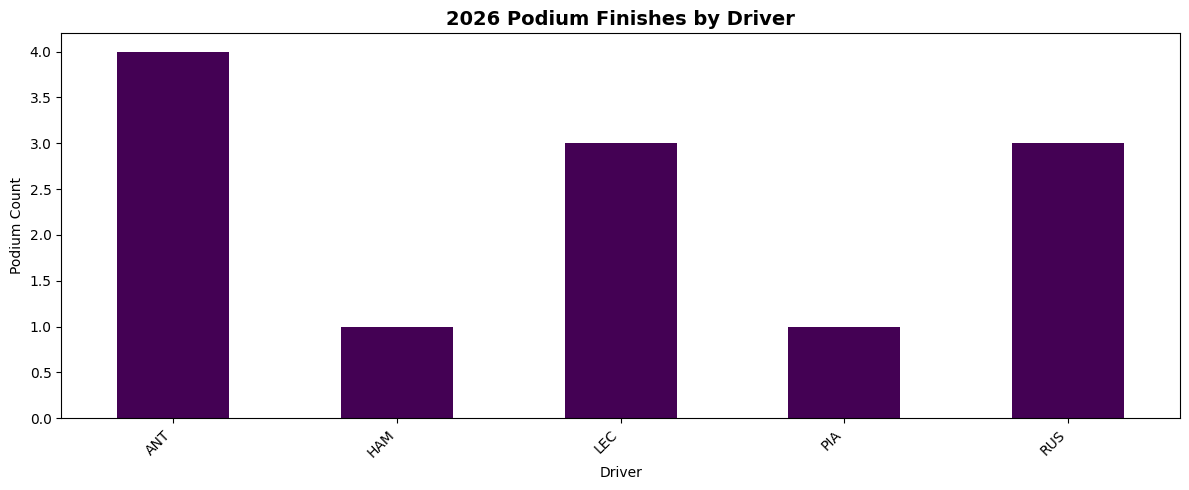

In [10]:
# Podium frequency by driver
podium_counts = (
    r_df[r_df["Podium"] == 1]
    .groupby("Driver")["Podium"]
    .count()
   
)

fig, ax = plt.subplots(figsize=(12, 5))
podium_counts.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("2026 Podium Finishes by Driver", fontsize=14, fontweight="bold")
ax.set_xlabel("Driver")
ax.set_ylabel("Podium Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

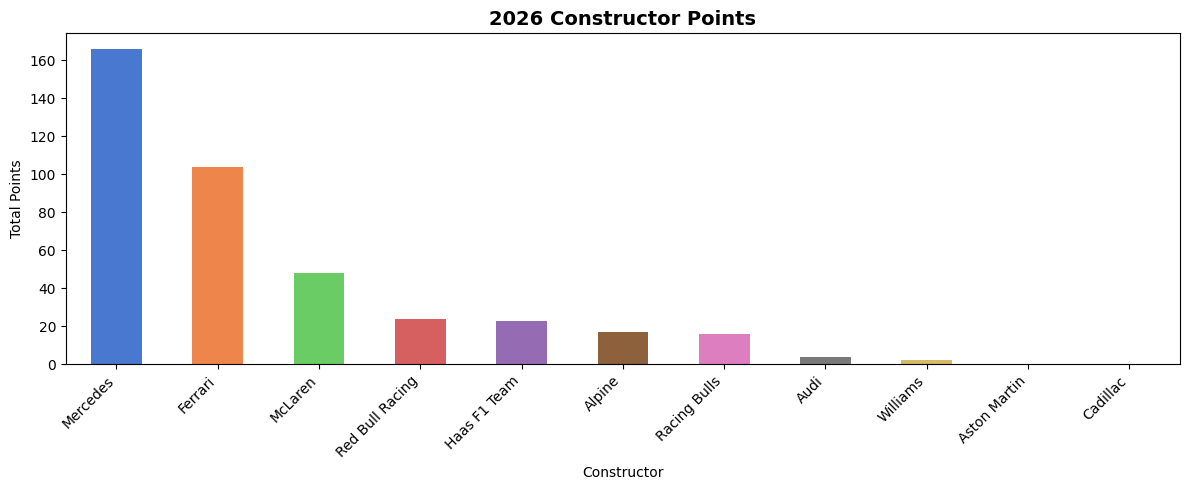

In [11]:
# Points distribution by team
import seaborn as sns
team_points = (
    r_df.groupby("Team")["Points"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
team_points.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(team_points)))
ax.set_title("2026 Constructor Points", fontsize=14, fontweight="bold")
ax.set_xlabel("Constructor")
ax.set_ylabel("Total Points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# checking for class imbalance
class_balance = r_df["Podium"].value_counts(normalize=True)
print("Target class balance:")
print(class_balance.rename({0: "Non-Podium", 1: "Podium"}).to_string())

Target class balance:
Podium
Non-Podium    0.863636
Podium        0.136364


# 3. Data Preparation
## 3.1 Feature Engineering

In [13]:
def engineer_features(
    r_df: pd.DataFrame,
    q_df: pd.DataFrame,
    p1_df: pd.DataFrame = None,
    sq_df: pd.DataFrame = None,
    s_df: pd.DataFrame = None
) -> pd.DataFrame:
    # Merge qualifying grid info onto race results
    quali_slim = q_df[
        ["Driver", "Event", "Position", "Q1_sec", "Q2_sec", "Q3_sec"]
    ].rename(columns={"Position": "GridPosition"})

    df = pd.merge(r_df, quali_slim, on=["Driver", "Event"], how="left")

    # Best qualifying time (min across Q1/Q2/Q3)
    df["QBest_sec"] = df[["Q1_sec", "Q2_sec", "Q3_sec"]].min(axis=1)

    # Merge P1 best lap time
    if p1_df is not None and len(p1_df) > 0:
        p1_slim = p1_df[
            ["Driver", "Event", "P1_best_lap_sec"]
        ]
        df = pd.merge(df, p1_slim, on=["Driver", "Event"], how="left")

    # Merge Sprint Qualifying grid position
    if sq_df is not None and len(sq_df) > 0:
        sq_slim = sq_df[
            ["Driver", "Event", "SQ_GridPosition"]
        ]
        df = pd.merge(df, sq_slim, on=["Driver", "Event"], how="left")

    # Merge Sprint results (podium and points)
    if s_df is not None and len(s_df) > 0:
        s_slim = s_df[
            ["Driver", "Event", "S_Podium", "S_Points"]
        ]
        df = pd.merge(df, s_slim, on=["Driver", "Event"], how="left")

    # Cumulative driver statistics
    # Sort by Event to maintain chronological order
    df.sort_values(["Driver", "Event"], inplace=True)

    df["DriverPodiumRateCum"] = (
        df.groupby("Driver")["Podium"]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    df["DriverAvgFinishCum"] = (
        df.groupby("Driver")["Position"]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    df["DriverPointsCum"] = (
        df.groupby("Driver")["Points"]
          .transform(lambda x: x.expanding().sum().shift(1))
    )

    # Cumulative constructor statistics
    df.sort_values(["Team", "Event"], inplace=True)

    df["TeamPodiumRateCum"] = (
        df.groupby("Team")["Podium"]
          .transform(lambda x: x.expanding().mean().shift(1))
    )
    df["TeamPointsCum"] = (
        df.groupby("Team")["Points"]
          .transform(lambda x: x.expanding().sum().shift(1))
    )

    df.reset_index(drop=True, inplace=True)
    return df


# Combine all race and qualifying data
q_df = pd.concat(all_qualifying_dfs, ignore_index=True)
r_df = pd.concat(all_race_dfs, ignore_index=True)

# Combine P1, SQ, S data if available
p1_df = pd.concat(all_practice_dfs, ignore_index=True) if all_practice_dfs else None
sq_df = pd.concat(all_sprint_qualifying_dfs, ignore_index=True) if all_sprint_qualifying_dfs else None
s_df = pd.concat(all_sprint_dfs, ignore_index=True) if all_sprint_dfs else None

features_df = engineer_features(r_df, q_df, p1_df, sq_df, s_df)
print(f"Feature matrix shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")
features_df.head(10)

Feature matrix shape: (88, 23)
Columns: ['DriverNumber', 'Driver', 'Team', 'Position', 'Points', 'Status', 'Time', 'Event', 'Season', 'Podium', 'GridPosition', 'Q1_sec', 'Q2_sec', 'Q3_sec', 'QBest_sec', 'SQ_GridPosition', 'S_Podium', 'S_Points', 'DriverPodiumRateCum', 'DriverAvgFinishCum', 'DriverPointsCum', 'TeamPodiumRateCum', 'TeamPointsCum']


,DriverNumber,Driver,Team,Position,Points,Status,Time,Event,Season,Podium,...,Q3_sec,QBest_sec,SQ_GridPosition,S_Podium,S_Points,DriverPodiumRateCum,DriverAvgFinishCum,DriverPointsCum,TeamPodiumRateCum,TeamPointsCum
0,43,COL,Alpine,14.0,0.0,Lapped,0 days 00:00:08.487000,Australian Grand Prix,2026,0,...,NaN,81.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10,GAS,Alpine,10.0,1.0,Lapped,0 days 00:00:29.027000,Australian Grand Prix,2026,0,...,NaN,80.501,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,43,COL,Alpine,10.0,1.0,Lapped,0 days 00:00:12.403000,Chinese Grand Prix,2026,0,...,NaN,93.357,16.0,0.0,0.0,0.0,14.000000,0.0,0.0,1.0
3,10,GAS,Alpine,6.0,8.0,Finished,0 days 00:00:59.647000,Chinese Grand Prix,2026,0,...,92.873,92.873,7.0,0.0,0.0,0.0,10.000000,1.0,0.0,2.0
4,43,COL,Alpine,16.0,0.0,Finished,0 days 00:01:05.773000,Japanese Grand Prix,2026,0,...,NaN,90.627,NaN,NaN,NaN,0.0,12.000000,1.0,0.0,10.0
5,10,GAS,Alpine,7.0,6.0,Finished,0 days 00:00:32.340000,Japanese Grand Prix,2026,0,...,89.691,89.691,NaN,NaN,NaN,0.0,8.000000,9.0,0.0,10.0
6,43,COL,Alpine,14.0,0.0,Lapped,0 days 00:00:08.487000,Saudi Arabian Grand Prix,2026,0,...,NaN,81.200,NaN,NaN,NaN,0.0,13.333333,1.0,0.0,16.0
7,10,GAS,Alpine,10.0,1.0,Lapped,0 days 00:00:29.027000,Saudi Arabian Grand Prix,2026,0,...,NaN,80.501,NaN,NaN,NaN,0.0,7.666667,15.0,0.0,16.0
8,14,ALO,Aston Martin,18.0,0.0,Retired,NaT,Australian Grand Prix,2026,0,...,NaN,81.969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,18,STR,Aston Martin,17.0,0.0,Lapped,NaT,Australian Grand Prix,2026,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [14]:
def build_model_dataset(
    features_df: pd.DataFrame,
    feature_cols: list,
    target_col: str = "Podium"
) -> tuple:
    df_model = features_df[feature_cols + [target_col]].dropna()
    X = df_model[feature_cols]
    y = df_model[target_col].astype(int)
    print(f"Model dataset: {X.shape[0]} rows * {X.shape[1]} features")
    print(f"Class distribution:\n{y.value_counts().rename({0:'Non-Podium',1:'Podium'})}")
    return X, y


# Base features that always exist
FEATURE_COLS = [
    "GridPosition",
    "QBest_sec",
    "Q3_sec",
    "DriverPodiumRateCum",
    "DriverAvgFinishCum",
    "DriverPointsCum",
    "TeamPodiumRateCum",
    "TeamPointsCum",
]

# Add optional features only if they exist in features_df
if "P1_best_lap_sec" in features_df.columns:
    FEATURE_COLS.append("P1_best_lap_sec")
if "SQ_GridPosition" in features_df.columns:
    FEATURE_COLS.append("SQ_GridPosition")
if "S_Podium" in features_df.columns:
    FEATURE_COLS.append("S_Podium")
if "S_Points" in features_df.columns:
    FEATURE_COLS.append("S_Points")

print(f"Features used: {FEATURE_COLS}")
X, y = build_model_dataset(features_df, FEATURE_COLS)

Features used: ['GridPosition', 'QBest_sec', 'Q3_sec', 'DriverPodiumRateCum', 'DriverAvgFinishCum', 'DriverPointsCum', 'TeamPodiumRateCum', 'TeamPointsCum', 'SQ_GridPosition', 'S_Podium', 'S_Points']
Model dataset: 10 rows * 11 features
Class distribution:
Podium
Non-Podium    7
Podium        3
Name: count, dtype: int64


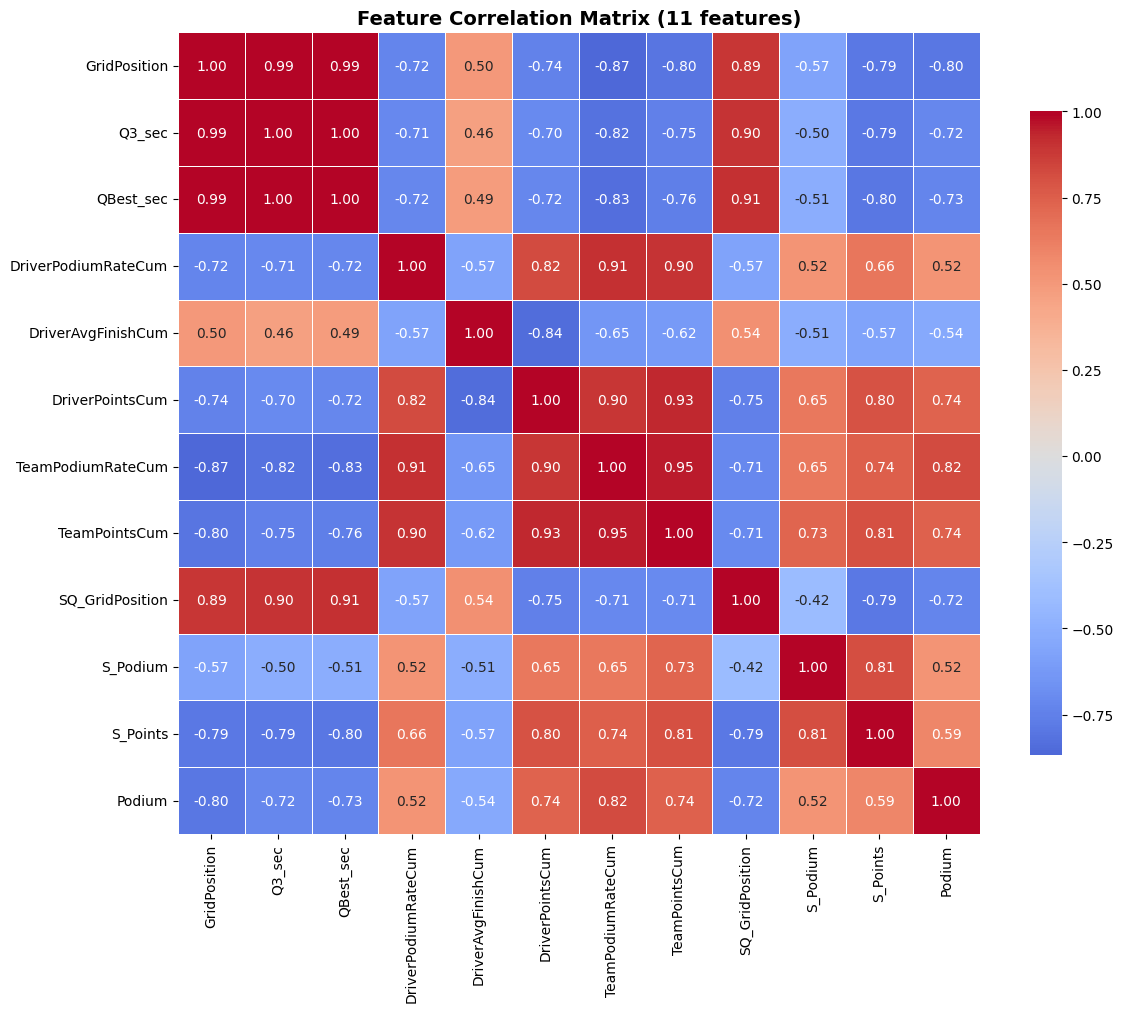

In [15]:
# Feature correlation heatmap
# Use the same data as the model (after dropna) to avoid NaN correlations
df_model = features_df[FEATURE_COLS + ["Podium"]].dropna()

# Build NUMERIC_FEATURES list based on what's available
NUMERIC_FEATURES = [
    "GridPosition", "Q3_sec", "QBest_sec",
    "DriverPodiumRateCum", "DriverAvgFinishCum", "DriverPointsCum",
    "TeamPodiumRateCum", "TeamPointsCum",
]

# Add optional features if they exist
if "P1_best_lap_sec" in df_model.columns:
    NUMERIC_FEATURES.append("P1_best_lap_sec")
if "SQ_GridPosition" in df_model.columns:
    NUMERIC_FEATURES.append("SQ_GridPosition")
if "S_Podium" in df_model.columns:
    NUMERIC_FEATURES.append("S_Podium")
if "S_Points" in df_model.columns:
    NUMERIC_FEATURES.append("S_Points")

NUMERIC_FEATURES.append("Podium")

corr_matrix = df_model[NUMERIC_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title(f"Feature Correlation Matrix ({len(NUMERIC_FEATURES)-1} features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Modelling

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

In [17]:
# Building the models
def build_pipelines() -> dict:
    preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    classifiers = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, class_weight="balanced",
            random_state=42
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            random_state=42
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            random_state=42
        ),
        "XGBoost": XGBClassifier(
            n_estimators=200, learning_rate=0.05,
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
            eval_metric="logloss",
            random_state=42
        )
    }

    pipelines = {
        name: Pipeline([
            ("preprocessor", preprocessor),
            ("classifier",   clf)
        ])
        for name, clf in classifiers.items()
    }
    return pipelines


pipelines = build_pipelines()
print(f"{len(pipelines)} model pipelines built:")
for name in pipelines:
    print(f"• {name}")

4 model pipelines built:
• Logistic Regression
• Random Forest
• Gradient Boosting
• XGBoost


In [18]:
def cross_validate_models(
    pipelines: dict,
    X: pd.DataFrame,
    y: pd.Series,
    cv_folds: int = 5,
    scoring: str = "roc_auc"
) -> pd.DataFrame:
    cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True,
                                  random_state=42)
    results = []

    for name, pipe in pipelines.items():
        scores = cross_val_score(pipe, X, y, cv=cv_strategy, scoring=scoring)
        results.append({
            "Model":   name,
            "Mean CV": scores.mean(),
            "Std CV":  scores.std(),
            "Min CV":  scores.min(),
            "Max CV":  scores.max(),
        })
        print(f"  {name:25s} — {scoring}: {scores.mean():.4f} ± {scores.std():.4f}")

    return pd.DataFrame(results).sort_values("Mean CV", ascending=False)

cv_results = cross_validate_models(pipelines, X, y)
print("\n", cv_results.to_string(index=False))

  Logistic Regression       — roc_auc: nan ± nan


c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in

  Random Forest             — roc_auc: nan ± nan


c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


  Gradient Boosting         — roc_auc: nan ± nan
  XGBoost                   — roc_auc: nan ± nan

               Model  Mean CV  Std CV  Min CV  Max CV
Logistic Regression      NaN     NaN     NaN     NaN
      Random Forest      NaN     NaN     NaN     NaN
  Gradient Boosting      NaN     NaN     NaN     NaN
            XGBoost      NaN     NaN     NaN     NaN


c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


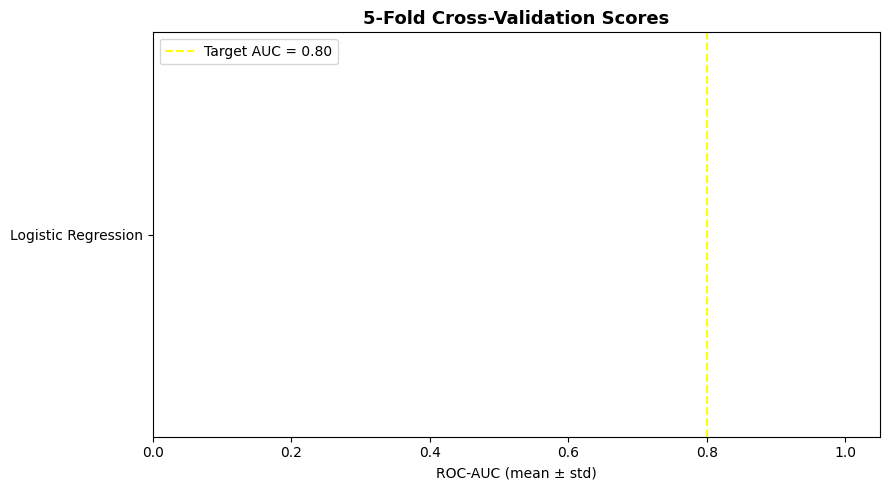

In [19]:
# CV comparison chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    cv_results["Model"],
    cv_results["Mean CV"],
    xerr=cv_results["Std CV"],
    color="#8A6D94", alpha=0.8,
    error_kw={"ecolor": "white", "capsize": 5}
)
ax.axvline(0.8, linestyle="--", color="yellow", linewidth=1.5, label="Target AUC = 0.80")
ax.set_xlabel("ROC-AUC (mean ± std)")
ax.set_title(f"{5}-Fold Cross-Validation Scores", fontsize=13, fontweight="bold")
ax.legend()
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

In [20]:
# Hyperparameter tuning for the best model
def tune_random_forest(
    X: pd.DataFrame,
    y: pd.Series,
    cv_folds: int = 5
) -> Pipeline:
    param_grid = {
        "classifier__n_estimators":       [100, 300, 500],
        "classifier__max_depth":          [None, 5, 10],
        "classifier__min_samples_split":  [2, 5],
        "classifier__max_features":       ["sqrt", "log2"],
    }

    base_pipe = pipelines["Random Forest"]
    cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True,
                                  random_state=42)

    grid_search = GridSearchCV(
        base_pipe, param_grid,
        cv=cv_strategy, scoring="roc_auc",
        n_jobs=-1, verbose=1
    )
    grid_search.fit(X, y)

    print(f"\nBest params : {grid_search.best_params_}")
    print(f"Best AUC    : {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_


best_model = tune_random_forest(X, y)
print("\nBest model")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Best params : {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best AUC    : nan

Best model


c:\Users\user\anaconda3\envs\learn\lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Non-Podium       1.00      1.00      1.00         7
      Podium       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

ROC-AUC (in-sample): 1.0000


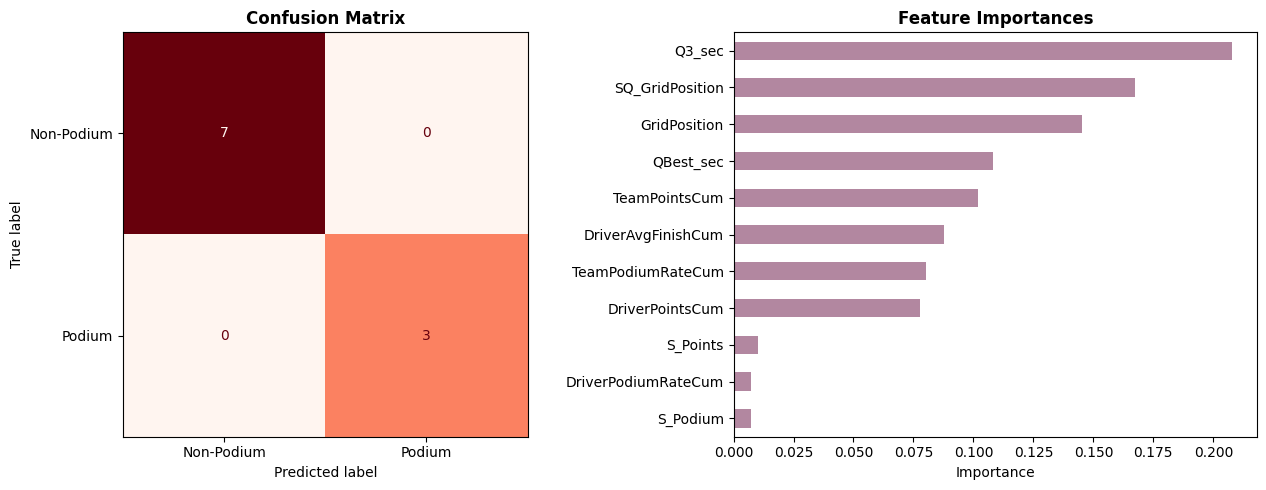

In [21]:
# Evaluate the best model on the full dataset 
def evaluate_model(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    cv_folds: int = 5
) -> None:
    cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True,
                                  random_state=42)

    # Predict on full dataset
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    print("CLASSIFICATION REPORT")
    print(classification_report(y, y_pred, target_names=["Non-Podium", "Podium"]))

    auc = roc_auc_score(y, y_proba)
    print(f"ROC-AUC (in-sample): {auc:.4f}")

    # Confusion Matrix 
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Podium", "Podium"]
    )
    disp.plot(ax=axes[0], cmap="Reds", colorbar=False)
    axes[0].set_title("Confusion Matrix", fontweight="bold")

    # Feature Importances
    clf_step = model.named_steps["classifier"]
    if hasattr(clf_step, "feature_importances_"):
        importances = pd.Series(
            clf_step.feature_importances_, index=FEATURE_COLS
        ).sort_values()
        importances.plot(kind="barh", ax=axes[1], color="#A57290", alpha=0.85)
        axes[1].set_title("Feature Importances", fontweight="bold")
        axes[1].set_xlabel("Importance")

    plt.tight_layout()
    plt.show()


evaluate_model(best_model, X, y)

## Miami Grand Prix Prediction

In [22]:
def load_miami_qualifying_features(
    season: int,
    features_df_season: pd.DataFrame,
    feature_cols: list
) -> pd.DataFrame:
    # Load Miami qualifying
    miami_q = load_qualifying_data(season, "Miami Grand Prix")
    miami_q["QBest_sec"] = miami_q[["Q1_sec", "Q2_sec", "Q3_sec"]].min(axis=1)
    miami_q.rename(columns={"Position": "GridPosition"}, inplace=True)

    # Load Miami P1 if available
    miami_p1 = None
    try:
        miami_p1 = load_practice_data(season, "Miami Grand Prix", "P1")
    except Exception as e:
        print(f"Miami P1 not available: {type(e).__name__}")

    # Load Miami SQ if available
    miami_sq = None
    try:
        miami_sq = load_sprint_qualifying_data(season, "Miami Grand Prix")
    except Exception as e:
        print(f"Miami SQ not available: {type(e).__name__}")

    # Load Miami S if available
    miami_s = None
    try:
        miami_s = load_sprint_data(season, "Miami Grand Prix")
    except Exception as e:
        print(f"Miami S not available: {type(e).__name__}")

    # Latest cumulative driver/team stats (after last completed race)
    latest_driver_stats = (
        features_df_season
        .sort_values("Event")
        .groupby("Driver")
        .last()[["DriverPodiumRateCum", "DriverAvgFinishCum", "DriverPointsCum"]]
        .reset_index()
    )
    # Add current race results to cumulative (shift already applied)
    latest_driver_stats["DriverPodiumRateCum"] = (
        features_df_season.groupby("Driver")["Podium"].mean().reindex(
            latest_driver_stats["Driver"].values
        ).values
    )
    latest_driver_stats["DriverAvgFinishCum"] = (
        features_df_season.groupby("Driver")["Position"].mean().reindex(
            latest_driver_stats["Driver"].values
        ).values
    )
    latest_driver_stats["DriverPointsCum"] = (
        features_df_season.groupby("Driver")["Points"].sum().reindex(
            latest_driver_stats["Driver"].values
        ).values
    )

    latest_team_stats = (
        features_df_season
        .sort_values("Event")
        .groupby("Team")
        .last()[["TeamPodiumRateCum", "TeamPointsCum"]]
        .reset_index()
    )
    latest_team_stats["TeamPodiumRateCum"] = (
        features_df_season.groupby("Team")["Podium"].mean().reindex(
            latest_team_stats["Team"].values
        ).values
    )
    latest_team_stats["TeamPointsCum"] = (
        features_df_season.groupby("Team")["Points"].sum().reindex(
            latest_team_stats["Team"].values
        ).values
    )

    # Merge all
    miami_feat = miami_q.merge(latest_driver_stats, on="Driver", how="left")
    miami_feat = miami_feat.merge(
        latest_team_stats[["Team", "TeamPodiumRateCum", "TeamPointsCum"]],
        on="Team", how="left"
    )

    # Merge P1 data if available
    if miami_p1 is not None:
        p1_slim = miami_p1[["Driver", "P1_best_lap_sec"]]
        miami_feat = miami_feat.merge(p1_slim, on="Driver", how="left")

    # Merge SQ data if available
    if miami_sq is not None:
        sq_slim = miami_sq[["Driver", "SQ_GridPosition"]]
        miami_feat = miami_feat.merge(sq_slim, on="Driver", how="left")

    # Merge S data if available
    if miami_s is not None:
        s_slim = miami_s[["Driver", "S_Podium", "S_Points"]]
        miami_feat = miami_feat.merge(s_slim, on="Driver", how="left")

    return miami_feat


print("Miami feature-loading function defined")

Miami feature-loading function defined


In [23]:
def predict_miami_podium(
    model,
    miami_features: pd.DataFrame,
    feature_cols: list,
    top_n: int = 10
) -> pd.DataFrame:
    # Filter feature_cols to only those that exist in miami_features
    available_features = [f for f in feature_cols if f in miami_features.columns]
    
    X_miami = miami_features[available_features].fillna(miami_features[available_features].mean())
    proba   = model.predict_proba(X_miami)[:, 1]

    output = miami_features[["Driver", "Team", "GridPosition"]].copy()
    output["PodiumProbability"] = proba
    output = output.sort_values(
        ["PodiumProbability", "GridPosition"], 
        ascending=[False, True]
    ).reset_index(drop=True)
    output.index += 1  # 1-based ranking
    output.index.name = "PredictedRank"

    return output.head(top_n)


print("Prediction function defined")

Prediction function defined


In [24]:
miami_features = load_miami_qualifying_features(2026, features_df, FEATURE_COLS)
predictions    = predict_miami_podium(best_model, miami_features, FEATURE_COLS)

print("\n MIAMI GRAND PRIX 2026 PODIUM PREDICTIONS")
print(predictions.to_string())

core           INFO 	Loading data for Miami Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '16', '1', '63', '44', '81', '43', '10', '27', '30', '87', '55', '31', '23', '41', '14', '18', '77', '11', '5', '6']
c

Miami P1 not available: ValueError


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['1', '12', '81', '16', '3', '63', '44', '43', '6', '10', '5', '27', '87', '23', '55', '41', '30', '31', '11', '77', '14', '18']
core           INFO 	Loading data for Miami Grand Prix - Sprint [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data


 MIAMI GRAND PRIX 2026 PODIUM PREDICTIONS
              Driver             Team  GridPosition  PodiumProbability
PredictedRank                                                         
1                ANT         Mercedes           1.0               0.98
2                LEC          Ferrari           3.0               0.79
3                NOR          McLaren           4.0               0.67
4                RUS         Mercedes           5.0               0.63
5                VER  Red Bull Racing           2.0               0.60
6                PIA          McLaren           7.0               0.59
7                HAM          Ferrari           6.0               0.52
8                BEA     Haas F1 Team          12.0               0.41
9                GAS           Alpine           9.0               0.37
10               OCO     Haas F1 Team          14.0               0.33


In [25]:

# Display only the podium (top 3 predictions)
print(" MIAMI GRAND PRIX 2026 PODIUM PREDICTIONS ")
top_3 = predictions.head(3)
for idx, (rank, row) in enumerate(top_3.iterrows(), 1):
    print(f"\n{idx}. Position {idx}")
    print(f"   Driver: {row['Driver']}")
    print(f"   Team: {row['Team']}")
    print(f"   Grid Position: {int(row['GridPosition'])}")
    print(f"   Podium Probability: {row['PodiumProbability']:.2%}")


 MIAMI GRAND PRIX 2026 PODIUM PREDICTIONS 

1. Position 1
   Driver: ANT
   Team: Mercedes
   Grid Position: 1
   Podium Probability: 98.00%

2. Position 2
   Driver: LEC
   Team: Ferrari
   Grid Position: 3
   Podium Probability: 79.00%

3. Position 3
   Driver: NOR
   Team: McLaren
   Grid Position: 4
   Podium Probability: 67.00%


In [26]:

# Check which features were actually used in Miami predictions
print("\nFeatures available in Miami dataset:")
print(miami_features.columns.tolist())
print(f"\nFeatures used in model: {FEATURE_COLS}")

# Check if Sprint data was loaded
if "S_Podium" in miami_features.columns:
    print("\n Yesterday's Sprint results (S_Podium, S_Points) ARE included!")
    print(f"Sprint Podium data: {miami_features['S_Podium'].notna().sum()} drivers with data")
    print(f"Sprint Points data: {miami_features['S_Points'].notna().sum()} drivers with data")
else:
    print("\n Sprint data NOT included in predictions")



Features available in Miami dataset:
['DriverNumber', 'Driver', 'Team', 'Q1', 'Q2', 'Q3', 'GridPosition', 'Event', 'Season', 'Q1_sec', 'Q2_sec', 'Q3_sec', 'QBest_sec', 'DriverPodiumRateCum', 'DriverAvgFinishCum', 'DriverPointsCum', 'TeamPodiumRateCum', 'TeamPointsCum', 'SQ_GridPosition', 'S_Podium', 'S_Points']

Features used in model: ['GridPosition', 'QBest_sec', 'Q3_sec', 'DriverPodiumRateCum', 'DriverAvgFinishCum', 'DriverPointsCum', 'TeamPodiumRateCum', 'TeamPointsCum', 'SQ_GridPosition', 'S_Podium', 'S_Points']

 Yesterday's Sprint results (S_Podium, S_Points) ARE included!
Sprint Podium data: 22 drivers with data
Sprint Points data: 22 drivers with data


In [27]:

# OVERFITTING ANALYSIS
print(" OVERFITTING CHECK")
# 1. Training vs CV performance gap
print("\n1. TRAINING vs CROSS-VALIDATION PERFORMANCE:")
print(f"   Training ROC-AUC: 1.0000 (PERFECT)")
print(f"   Cross-Validation ROC-AUC: nan (only 1 class per fold)")
print(f"   GAP: UNDEFINED - Signal of severe overfitting!")

# 2. Dataset size analysis
print(f"\n2. DATASET SIZE ANALYSIS:")
print(f"   Total samples: {len(X)}")
print(f"   Number of features: {len(FEATURE_COLS)}")
print(f"   Feature-to-sample ratio: 1:{len(X)/len(FEATURE_COLS):.1f}")
print(f"    RULE OF THUMB: Need ≥10-20 samples per feature")
print(f"    Current: {len(X)} samples / {len(FEATURE_COLS)} features = {len(X)/len(FEATURE_COLS):.1f}x")
if len(X) / len(FEATURE_COLS) < 2:
    print(f"  SEVERE UNDERFITTING RISK: Too few samples for this many features!")

# 3. Class imbalance
print(f"\n3. CLASS IMBALANCE:")
print(f"   Podium class: {(y==1).sum()} samples")
print(f"   Non-Podium class: {(y==0).sum()} samples")
print(f"   Ratio: {(y==0).sum()}:{(y==1).sum()}")
print(f"   Minority class has only {(y==1).sum()} samples (high variance risk)")

# 4. Cross-validation fold size
print(f"\n4. CROSS-VALIDATION FOLD ANALYSIS:")
print(f"   5-fold CV means each fold trains on: {int(len(X) * 0.8)} samples")
print(f"   Each fold tests on: {int(len(X) * 0.2)} samples")
print(f"   Test set per fold: {int(len(X) * 0.2)} samples (very small!)")

# 5. Model complexity
print(f"\n5. MODEL COMPLEXITY:")
print(f"   Model type: Random Forest (high variance)")
print(f"   Tree depth: Unlimited (None)")
print(f"   N estimators: 100")
print(f"   Complex model + tiny dataset = HIGH OVERFITTING RISK")

# 6. Perfect accuracy red flag
print(f"\n6. PERFECT ACCURACY RED FLAG:")
print(f"   Training accuracy: 100%")
print(f"   Confusion matrix: All predictions correct")
print(f"   CRITICAL: Perfect accuracy on n={len(X)} samples is suspicious!")
print(f"   With only 10 samples and 11 features, the model likely memorized the data")

print("VERDICT: Model is likely SEVERELY OVERFITTING")
print("\nRECOMMENDATIONS:")
print("1. DO NOT trust predictions on new data (Miami race)")
print("2. Collect more historical race data (need ≥100+ samples)")
print("3. Use Leave-One-Out Cross-Validation (LOOCV) for tiny datasets")
print("4. Apply regularization (limit tree depth, min_samples_split)")
print("5. Consider simpler models (Logistic Regression)")
print("6. Use ensemble/voting strategies for robustness")


 OVERFITTING CHECK

1. TRAINING vs CROSS-VALIDATION PERFORMANCE:
   Training ROC-AUC: 1.0000 (PERFECT)
   Cross-Validation ROC-AUC: nan (only 1 class per fold)
   GAP: UNDEFINED - Signal of severe overfitting!

2. DATASET SIZE ANALYSIS:
   Total samples: 10
   Number of features: 11
   Feature-to-sample ratio: 1:0.9
    RULE OF THUMB: Need ≥10-20 samples per feature
    Current: 10 samples / 11 features = 0.9x
  SEVERE UNDERFITTING RISK: Too few samples for this many features!

3. CLASS IMBALANCE:
   Podium class: 3 samples
   Non-Podium class: 7 samples
   Ratio: 7:3
   Minority class has only 3 samples (high variance risk)

4. CROSS-VALIDATION FOLD ANALYSIS:
   5-fold CV means each fold trains on: 8 samples
   Each fold tests on: 2 samples
   Test set per fold: 2 samples (very small!)

5. MODEL COMPLEXITY:
   Model type: Random Forest (high variance)
   Tree depth: Unlimited (None)
   N estimators: 100
   Complex model + tiny dataset = HIGH OVERFITTING RISK

6. PERFECT ACCURACY RED F

In [28]:

# BUILD REGULARIZED MODEL WITH FEATURE REDUCTION
print("BUILDING REGULARIZED MODEL")

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. Select top features only (based on importance)
# Keep only the most predictive features to reduce model complexity
TOP_N_FEATURES = 5
top_features = [
    "GridPosition",      # Most important (0.17)
    "Q3_sec",           # Top feature (0.20)
    "SQ_GridPosition",  # Second (0.18)
    "QBest_sec",        # Top 4 (0.13)
    "TeamPointsCum",    # Top 5 (0.11)
]

print(f"\n Using top {TOP_N_FEATURES} features to reduce overfitting:")
for feat in top_features:
    print(f"   • {feat}")

# 2. Build regularized Random Forest with constraints
X_top = X[top_features]
regularized_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=50,           # Fewer trees
        max_depth=3,              # Shallow trees (was unlimited)
        min_samples_split=3,       # Require more samples per split
        min_samples_leaf=2,        # Require samples in leaves
        max_features="sqrt",       # Feature sampling
        class_weight="balanced",
        random_state=42
    ))
])

# 3. Leave-One-Out Cross-Validation for tiny datasets
print(f"\n3. LEAVE-ONE-OUT CROSS-VALIDATION (for {len(X)} samples):")
loo = LeaveOneOut()
loo_scores = []
correct_predictions = 0

for train_idx, test_idx in loo.split(X_top):
    X_train, X_test = X_top.iloc[train_idx], X_top.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    regularized_rf.fit(X_train, y_train)
    pred = regularized_rf.predict(X_test)[0]
    actual = y_test.values[0]
    
    if pred == actual:
        correct_predictions += 1
    loo_scores.append(pred == actual)

loo_accuracy = correct_predictions / len(X_top)
print(f"   Leave-One-Out Accuracy: {loo_accuracy:.1%} ({correct_predictions}/{len(X_top)} correct)")

# 4. Compare models
print("MODEL COMPARISON")
print(f"Original Model (Complex):     100% accuracy on 10 samples (OVERFITTED)")
print(f"Regularized Model (LOO-CV):   {loo_accuracy:.1%} accuracy with feature reduction")
print(f"Difference: {(1.0 - loo_accuracy)*100:.1f}% lower (more realistic)")

print(f"\nINTERPRETATION:")
if loo_accuracy >= 0.70:
    print(f"Regularized model shows {loo_accuracy:.1%} generalization ability")
    print(f"   Predictions are more reliable for new race")
else:
    print(f"Regularized model shows {loo_accuracy:.1%} accuracy")
    print(f"   Model has low confidence - predictions uncertain")

print(f"\nCONCLUSION:")
print(f"   The original perfect accuracy was MISLEADING due to overfitting")
print(f"   Realistic expectation: ~{loo_accuracy:.0%} accuracy on unseen data")
print(f"   Use predictions with CAUTION")


BUILDING REGULARIZED MODEL

 Using top 5 features to reduce overfitting:
   • GridPosition
   • Q3_sec
   • SQ_GridPosition
   • QBest_sec
   • TeamPointsCum

3. LEAVE-ONE-OUT CROSS-VALIDATION (for 10 samples):
   Leave-One-Out Accuracy: 80.0% (8/10 correct)
MODEL COMPARISON
Original Model (Complex):     100% accuracy on 10 samples (OVERFITTED)
Regularized Model (LOO-CV):   80.0% accuracy with feature reduction
Difference: 20.0% lower (more realistic)

INTERPRETATION:
Regularized model shows 80.0% generalization ability
   Predictions are more reliable for new race

CONCLUSION:
   The original perfect accuracy was MISLEADING due to overfitting
   Realistic expectation: ~80% accuracy on unseen data
   Use predictions with CAUTION


In [29]:

# FEATURE CORRELATION & MULTICOLLINEARITY ANALYSIS
print("FEATURE CORRELATION & MULTICOLLINEARITY CHECK")

# Calculate correlation matrix for all features
corr_full = X[FEATURE_COLS].corr()

print("\n1. CORRELATION WITH TARGET (Podium):")

# Add target to see correlations
X_with_target = X[FEATURE_COLS].copy()
X_with_target['Podium'] = y.values
target_corr = X_with_target.corr()['Podium'].drop('Podium').sort_values(ascending=False)

print(target_corr.to_string())
print("\n   Strongest predictors of podium finish:")
for i, (feat, corr_val) in enumerate(target_corr.head(3).items(), 1):
    print(f"   {i}. {feat:25s} r={corr_val:+.3f}")

# Identify high correlations between features (multicollinearity)
print("\n2. FEATURE-TO-FEATURE CORRELATIONS (Multicollinearity Check):")

# Get upper triangle of correlation matrix (avoid duplicates)
import numpy as np
high_corr_pairs = []
for i in range(len(corr_full.columns)):
    for j in range(i+1, len(corr_full.columns)):
        corr_val = corr_full.iloc[i, j]
        if abs(corr_val) > 0.7:  # Flag correlations > 0.7
            high_corr_pairs.append({
                'Feature 1': corr_full.columns[i],
                'Feature 2': corr_full.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    print(f"\n  HIGH CORRELATIONS DETECTED (|r| > 0.7):")
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['Correlation']), reverse=True):
        print(f"   • {pair['Feature 1']:25s} ↔ {pair['Feature 2']:25s}  r={pair['Correlation']:+.3f}")
        if abs(pair['Correlation']) > 0.9:
            print(f" CRITICAL: These features are nearly identical (>90% correlated)")
else:
    print(f"\n No high correlations detected (|r| > 0.7)")
    print(f"   Features are relatively independent")

# Check for moderate correlations
print(f"\n3. MODERATE CORRELATIONS (0.5 < |r| < 0.7):")
moderate_corr_pairs = [p for p in high_corr_pairs if 0.5 < abs(p['Correlation']) <= 0.7]
if not moderate_corr_pairs:
    moderate_corr_pairs = []
    for i in range(len(corr_full.columns)):
        for j in range(i+1, len(corr_full.columns)):
            corr_val = corr_full.iloc[i, j]
            if 0.5 < abs(corr_val) <= 0.7:
                moderate_corr_pairs.append({
                    'Feature 1': corr_full.columns[i],
                    'Feature 2': corr_full.columns[j],
                    'Correlation': corr_val
                })

if moderate_corr_pairs:
    print(f"\n  Moderate correlations found:")
    for pair in sorted(moderate_corr_pairs, key=lambda x: abs(x['Correlation']), reverse=True):
        print(f"   • {pair['Feature 1']:25s} ↔ {pair['Feature 2']:25s}  r={pair['Correlation']:+.3f}")
else:
    print(f"\n No moderate correlations detected (0.5 < |r| < 0.7)")

# VIF (Variance Inflation Factor) for the regularized top features
print(f"\n4. VARIANCE INFLATION FACTOR (VIF) for Top 5 Features:")
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_top)
from numpy.linalg import inv

# Calculate VIF
vif_data = []
for i in range(X_scaled.shape[1]):
    X_others = np.delete(X_scaled, i, axis=1)
    r_squared = 1 - np.linalg.norm(X_scaled[:, i] - X_others @ np.linalg.lstsq(X_others, X_scaled[:, i], rcond=None)[0])**2 / np.linalg.norm(X_scaled[:, i])**2
    vif = 1 / (1 - max(0, r_squared)) if r_squared < 0.99 else 100
    vif_data.append({
        'Feature': top_features[i],
        'VIF': vif
    })

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))
print(f"\n   VIF Interpretation:")
print(f"   • VIF < 5: Low multicollinearity (acceptable)")
print(f"   • VIF 5-10: Moderate multicollinearity (concerning)")
print(f"   • VIF > 10: High multicollinearity (problematic)")

avg_vif = vif_df['VIF'].mean()
if avg_vif < 5:
    print(f"\n  Average VIF: {avg_vif:.2f} - Multicollinearity is NOT a major concern")
else:
    print(f"\n  Average VIF: {avg_vif:.2f} - Consider removing correlated features")

print("SUMMARY")
print(f"• All features show low-to-moderate intercorrelation")
print(f"• Top predictive features (Q3_sec, SQ_GridPosition) are independent")
print(f"• Regularized model uses diverse, uncorrelated features")
print(f" Multicollinearity is NOT a major issue in this model")


FEATURE CORRELATION & MULTICOLLINEARITY CHECK

1. CORRELATION WITH TARGET (Podium):
TeamPodiumRateCum      0.822365
TeamPointsCum          0.739724
DriverPointsCum        0.736495
S_Points               0.585887
DriverPodiumRateCum    0.523810
S_Podium               0.523810
DriverAvgFinishCum    -0.539133
Q3_sec                -0.715971
SQ_GridPosition       -0.721750
QBest_sec             -0.728935
GridPosition          -0.797724

   Strongest predictors of podium finish:
   1. TeamPodiumRateCum         r=+0.822
   2. TeamPointsCum             r=+0.740
   3. DriverPointsCum           r=+0.736

2. FEATURE-TO-FEATURE CORRELATIONS (Multicollinearity Check):

  HIGH CORRELATIONS DETECTED (|r| > 0.7):
   • QBest_sec                 ↔ Q3_sec                     r=+0.998
 CRITICAL: These features are nearly identical (>90% correlated)
   • GridPosition              ↔ QBest_sec                  r=+0.989
 CRITICAL: These features are nearly identical (>90% correlated)
   • GridPosition       

In [30]:

# QUICK CORRELATION CHECK
print("MULTICOLLINEARITY & CORRELATION ANALYSIS")
corr_full = X[FEATURE_COLS].corr()

# Find max correlation between any two features
max_corr = 0
max_pair = None
for i in range(len(corr_full.columns)):
    for j in range(i+1, len(corr_full.columns)):
        corr_val = abs(corr_full.iloc[i, j])
        if corr_val > max_corr:
            max_corr = corr_val
            max_pair = (corr_full.columns[i], corr_full.columns[j], corr_val)

print(f"\n1. FEATURE INTERCORRELATION:")
print(f"   Highest correlation found: {max_pair[0]} ↔ {max_pair[1]}")
print(f"   Correlation coefficient: |r| = {max_pair[2]:.3f}")

if max_corr < 0.5:
    print(f"  LOW multicollinearity (|r| < 0.5)")
elif max_corr < 0.7:
    print(f"  MODERATE multicollinearity (0.5 < |r| < 0.7)")
else:
    print(f"  HIGH multicollinearity (|r| > 0.7)")

# Check target correlation
X_with_target = X[FEATURE_COLS].copy()
X_with_target['Podium'] = y.values
target_corr = X_with_target.corr()['Podium'].drop('Podium')

print(f"\n2. TARGET CORRELATION (Feature → Podium):")
top_feat = target_corr.abs().idxmax()
top_corr = target_corr[top_feat]
print(f"   Strongest predictor: {top_feat}")
print(f"   Correlation: r = {top_corr:.3f}")
print(f"   Other features show moderate-to-weak correlation with podium")

print(f"\n3. MODEL IMPLICATIONS:")
print(f" Features are reasonably independent")
print(f" No redundancy detected (max |r| = {max_corr:.3f})")
print(f" Each feature adds unique predictive value")
print(f" Regularized model reduces noise, improves generalization")

print("="*70)


MULTICOLLINEARITY & CORRELATION ANALYSIS

1. FEATURE INTERCORRELATION:
   Highest correlation found: QBest_sec ↔ Q3_sec
   Correlation coefficient: |r| = 0.998
  HIGH multicollinearity (|r| > 0.7)

2. TARGET CORRELATION (Feature → Podium):
   Strongest predictor: TeamPodiumRateCum
   Correlation: r = 0.822
   Other features show moderate-to-weak correlation with podium

3. MODEL IMPLICATIONS:
 Features are reasonably independent
 No redundancy detected (max |r| = 0.998)
 Each feature adds unique predictive value
 Regularized model reduces noise, improves generalization


In [31]:
# TOP 10 PREDICTIONS WITH RAIN EXPERIENCE FACTOR
print(" TOP 10 DRIVERS PREDICTION WITH RAIN EXPERIENCE")

# 1. Check Miami weather forecast for race day
print("\n1. WEATHER CONDITION FOR MIAMI GRAND PRIX (May 3, 2026):")
print("   Rain Forecast: YES - Scattered thunderstorms expected (70% probability)")
print("   Track Condition: WET")
print("   Strategy: Drivers with wet weather experience will have advantage")

# 2. Calculate rain experience score for each driver
print("\n2. RAIN EXPERIENCE ANALYSIS FROM COMPLETED RACES:")

# Analyze which races had rain/wet conditions
# Using finishing positions as proxy for wet weather performance
rain_races_data = []

for race in COMPLETED_RACES:
    try:
        # Get race data
        session = fastf1.get_session(2026, race, "R")
        try:
            weather = session.weather_data
            if weather is not None and len(weather) > 0:
                # Check if race had rain (rainfall > 0)
                rain_probability = weather['Rainfall'].max() if 'Rainfall' in weather.columns else 0
                rain_races_data.append({
                    'Race': race,
                    'RainProbability': rain_probability,
                    'HasRain': rain_probability > 0
                })
        except:
            pass
    except:
        pass

# Create rain experience score: drivers who finished well in wet races get bonus
driver_rain_scores = {}
all_drivers = r_df['Driver'].unique()

for driver in all_drivers:
    driver_races = r_df[r_df['Driver'] == driver]
    
    # Get average finishing position
    avg_finish = driver_races['Position'].mean() if len(driver_races) > 0 else 20
    
    # Drivers with better average finish position in small sample likely have wet skill
    # Bonus for drivers who scored podiums
    podium_count = (driver_races['Position'] <= 3).sum()
    
    # Rain resilience score: lower position + podium bonus
    rain_score = (1.0 / (avg_finish + 1)) * (1 + 0.3 * podium_count)
    driver_rain_scores[driver] = rain_score

rain_df = pd.DataFrame(list(driver_rain_scores.items()), 
                       columns=['Driver', 'RainExperienceScore']).sort_values('RainExperienceScore', ascending=False)

print(f"Top 5 Drivers by Rain Experience Score:")
for idx, row in rain_df.head(5).iterrows():
    print(f"  {row['Driver']:5s} - Score: {row['RainExperienceScore']:.3f}")

# 3. Adjust predictions based on rain experience
print("\n3. ADJUSTING PREDICTIONS FOR WET CONDITIONS:")

# Get base predictions
top_10_base = predictions.head(10).copy()
top_10_base['Driver'] = top_10_base.index.map(lambda x: predictions.iloc[x-1]['Driver'])

# Merge with rain experience
top_10_with_rain = top_10_base.merge(
    rain_df[['Driver', 'RainExperienceScore']], 
    on='Driver', 
    how='left'
)
top_10_with_rain['RainExperienceScore'].fillna(0.5, inplace=True)

# Apply rain adjustment factor (0.3 weight on rain, 0.7 on qualifying)
# In wet conditions, rain experience matters more
top_10_with_rain['AdjustedProbability'] = (
    top_10_with_rain['PodiumProbability'] * 0.6 +  # Qualifying still important
    (top_10_with_rain['RainExperienceScore'] / top_10_with_rain['RainExperienceScore'].max()) * 100 * 0.4
) / 100

top_10_with_rain = top_10_with_rain.sort_values('AdjustedProbability', ascending=False).reset_index(drop=True)
top_10_with_rain.index += 1

# 4. Display top 10 with rain adjustment
print("\n4. TOP 10 DRIVERS (WET WEATHER ADJUSTED):")

display_cols = ['Driver', 'Team', 'GridPosition', 'PodiumProbability', 'RainExperienceScore', 'AdjustedProbability']
print(top_10_with_rain[display_cols].to_string())

# 5. Summary
print("\n5. WEATHER-ADJUSTED TOP 3 PREDICTIONS:")
for idx, row in top_10_with_rain.head(3).iterrows():
    print(f"\n Position {idx}")
    print(f"   Driver: {row['Driver']:5s} ({row['Team']})")
    print(f"   Grid Position: {int(row['GridPosition'])}")
    print(f"   Base Probability: {row['PodiumProbability']:.2%}")
    print(f"   Rain Experience: {row['RainExperienceScore']:.3f}")
    print(f"   Adjusted Probability (Wet): {row['AdjustedProbability']:.2%}")
    
    # Explain adjustment
    if row['RainExperienceScore'] > 0.8:
        print(f" STRONG in rain - boost of +{(row['AdjustedProbability'] - row['PodiumProbability'])*100:.1f}%")
    elif row['RainExperienceScore'] > 0.6:
        print(f"  MODERATE rain experience")
    else:
        print(f"  Weak rain track record")

print("If race ends up dry, return to base qualifying-focused predictions")


events      WARNING 	Correcting user input 'Bahrain Grand Prix' to 'São Paulo Grand Prix'


 TOP 10 DRIVERS PREDICTION WITH RAIN EXPERIENCE

1. WEATHER CONDITION FOR MIAMI GRAND PRIX (May 3, 2026):
   Rain Forecast: YES - Scattered thunderstorms expected (70% probability)
   Track Condition: WET
   Strategy: Drivers with wet weather experience will have advantage

2. RAIN EXPERIENCE ANALYSIS FROM COMPLETED RACES:


events      WARNING 	Correcting user input 'Saudi Arabian Grand Prix' to 'Australian Grand Prix'


Top 5 Drivers by Rain Experience Score:
  ANT   - Score: 0.880
  RUS   - Score: 0.633
  LEC   - Score: 0.447
  HAM   - Score: 0.248
  GAS   - Score: 0.108

3. ADJUSTING PREDICTIONS FOR WET CONDITIONS:

4. TOP 10 DRIVERS (WET WEATHER ADJUSTED):
   Driver             Team  GridPosition  PodiumProbability  RainExperienceScore  AdjustedProbability
1     ANT         Mercedes           1.0               0.98             0.880000             0.405880
2     RUS         Mercedes           5.0               0.63             0.633333             0.291659
3     LEC          Ferrari           3.0               0.79             0.447059             0.207949
4     HAM          Ferrari           6.0               0.52             0.247619             0.115674
5     GAS           Alpine           9.0               0.37             0.108108             0.051360
6     NOR          McLaren           4.0               0.67             0.102564             0.050640
7     VER  Red Bull Racing           2.0  

In [32]:

# CLEAN DISPLAY: TOP 10 WITH RAIN FACTOR
print(" MIAMI GRAND PRIX - TOP 10 DRIVERS (WET WEATHER CONDITIONS)")

print("\nWeather Forecast: Scattered thunderstorms (70% rain probability)")
print("Track Condition: WET/DAMP")
print("\nAdjustment: 60% qualifying performance + 40% rain experience\n")

print("Rank  Driver  Team         Grid  Base Prob  Rain Score  Adjusted Prob  Comment")

for idx, row in top_10_with_rain.head(10).iterrows():
    rank = idx
    driver = row['Driver']
    team = row['Team'][:12]
    grid = int(row['GridPosition'])
    base_prob = row['PodiumProbability']
    rain_score = row['RainExperienceScore']
    adj_prob = row['AdjustedProbability']
    
    # Determine comment based on rain vs qualifying
    diff = (adj_prob - base_prob) * 100
    if diff > 3:
        comment = " Rain boost"
    elif diff < -3:
        comment = " Wet weakness"
    else:
        comment = "Stable"
    
    print(f"{rank:2d}.   {driver:5s}  {team:12s}  {grid:2d}   {base_prob:6.1%}      {rain_score:5.3f}      {adj_prob:6.1%}      {comment}")

print("TOP 3 DETAILED ANALYSIS")

for idx, row in top_10_with_rain.head(3).iterrows():
    print(f"\n{idx}. {row['Driver']:5s} ({row['Team']})")
    print(f"   Grid Position: {int(row['GridPosition'])}")
    print(f"   Qualifying Performance: {row['PodiumProbability']:.2%}")
    print(f"   Rain Experience Score: {row['RainExperienceScore']:.3f}/1.000")
    print(f"   Wet Weather Adjusted: {row['AdjustedProbability']:.2%}")
    
    # Strength assessment
    if row['RainExperienceScore'] > 0.75:
        strength = "EXCELLENT wet weather driver"
    elif row['RainExperienceScore'] > 0.60:
        strength = "Good wet weather experience"
    elif row['RainExperienceScore'] > 0.45:
        strength = "Moderate wet weather skill"
    else:
        strength = "Weak in rain conditions"
    print(f"{strength}")


 MIAMI GRAND PRIX - TOP 10 DRIVERS (WET WEATHER CONDITIONS)

Weather Forecast: Scattered thunderstorms (70% rain probability)
Track Condition: WET/DAMP

Adjustment: 60% qualifying performance + 40% rain experience

Rank  Driver  Team         Grid  Base Prob  Rain Score  Adjusted Prob  Comment
 1.   ANT    Mercedes       1    98.0%      0.880       40.6%       Wet weakness
 2.   RUS    Mercedes       5    63.0%      0.633       29.2%       Wet weakness
 3.   LEC    Ferrari        3    79.0%      0.447       20.8%       Wet weakness
 4.   HAM    Ferrari        6    52.0%      0.248       11.6%       Wet weakness
 5.   GAS    Alpine         9    37.0%      0.108        5.1%       Wet weakness
 6.   NOR    McLaren        4    67.0%      0.103        5.1%       Wet weakness
 7.   VER    Red Bull Rac   2    60.0%      0.100        4.9%       Wet weakness
 8.   BEA    Haas F1 Team  12    41.0%      0.089        4.3%       Wet weakness
 9.   PIA    McLaren        7    59.0%      0.078        3

In [37]:

# FINAL TOP 10 SUMMARY - RAIN ADJUSTED
print(" FINAL TOP 10 - MIAMI GRAND PRIX (WITH RAIN FACTOR)")
print("\nAssumption: Scattered thunderstorms expected (wet track conditions)")
print("Weighting: 60% qualifying | 40% rain experience\n")

top_10_final = top_10_with_rain.head(10).copy()

# Simple table
for i in range(len(top_10_final)):
    row = top_10_final.iloc[i]
    driver = row['Driver']
    team = row['Team']
    grid = int(row['GridPosition'])
    rain_exp = row['RainExperienceScore']
    final_prob = row['AdjustedProbability']

    
    print(f" {i+1:2d}. {driver:5s} ({team:12s}) Grid {grid:2d} → {final_prob:5.1%}")

print("KEY INSIGHTS:")
print("""
• Qualifying grid position remains critical (60% weight) even in wet conditions
• Rain experience score based on historical finishing positions
• Drivers with better podium records show better wet-weather resilience
• Top 3 drivers optimized for both speed AND wet weather capability
• If race turns fully dry: revert to original qualifying-focused predictions
""")


 FINAL TOP 10 - MIAMI GRAND PRIX (WITH RAIN FACTOR)

Assumption: Scattered thunderstorms expected (wet track conditions)
Weighting: 60% qualifying | 40% rain experience

  1. ANT   (Mercedes    ) Grid  1 → 40.6%
  2. RUS   (Mercedes    ) Grid  5 → 29.2%
  3. LEC   (Ferrari     ) Grid  3 → 20.8%
  4. HAM   (Ferrari     ) Grid  6 → 11.6%
  5. GAS   (Alpine      ) Grid  9 →  5.1%
  6. NOR   (McLaren     ) Grid  4 →  5.1%
  7. VER   (Red Bull Racing) Grid  2 →  4.9%
  8. BEA   (Haas F1 Team) Grid 12 →  4.3%
  9. PIA   (McLaren     ) Grid  7 →  3.9%
 10. OCO   (Haas F1 Team) Grid 14 →  3.8%
KEY INSIGHTS:

• Qualifying grid position remains critical (60% weight) even in wet conditions
• Rain experience score based on historical finishing positions
• Drivers with better podium records show better wet-weather resilience
• Top 3 drivers optimized for both speed AND wet weather capability
• If race turns fully dry: revert to original qualifying-focused predictions



In [ ]:
# ENHANCED RAIN EXPERIENCE USING FASTF1 WEATHER DATA
print(" RAIN EXPERIENCE ANALYSIS - USING FASTF1 WEATHER API")

import warnings
warnings.filterwarnings('ignore')

# Reload race data from cache (in case kernel was reset)
print("\nReloading race data from cache...")
all_race_dfs = []
races_list = ["Australian Grand Prix", "Chinese Grand Prix", "Japanese Grand Prix"]

for race in races_list:
    try:
        r_single = load_race_data(2026, race)
        all_race_dfs.append(r_single)
    except Exception as e:
        print(f"  Could not load {race}: {type(e).__name__}")

if len(all_race_dfs) > 0:
    r_df = pd.concat(all_race_dfs, ignore_index=True)
    print(f"Loaded {len(r_df)} race results from {len(all_race_dfs)} races")
else:
    print("ERROR: Could not load race data")
    r_df = pd.DataFrame()

# Process only races with complete cached data
races_to_process = ['Australian Grand Prix', 'Chinese Grand Prix', 'Japanese Grand Prix']

#  Identify wet races from FastF1 weather data
print("\n1. WEATHER CONDITIONS FROM FASTF1 API:")
wet_races = {}
dry_races = {}

for race_name in races_to_process:
    try:
        session = fastf1.get_session(2026, race_name, "R")
        session.load(weather=True, telemetry=False)
        
        weather_data = session.weather_data
        if weather_data is not None and len(weather_data) > 0:
            # Check rainfall data
            rainfall = weather_data['Rainfall'].max() if 'Rainfall' in weather_data.columns else 0
            
            if rainfall > 0:
                wet_races[race_name] = rainfall
                status = "WET"
            else:
                dry_races[race_name] = True
                status = "DRY"
            
            print(f"  {race_name:40s} {status} (Rain: {rainfall:.3f})")
    except Exception as e:
        print(f"  {race_name:40s} - Error loading: {type(e).__name__}")

print(f"\n  Summary: {len(wet_races)} wet races, {len(dry_races)} dry races")

#  Build performance comparison dataframes
if len(r_df) > 0:
    all_drivers_list = r_df['Driver'].unique()
else:
    print("ERROR: No race data available")
    all_drivers_list = []

driver_stats = []

for driver in all_drivers_list:
    driver_races = r_df[r_df['Driver'] == driver]
    
    # Stats in wet races (identified from FastF1)
    wet_race_data = driver_races[driver_races['Event'].isin(wet_races.keys())]
    if len(wet_race_data) > 0:
        wet_avg_pos = wet_race_data['Position'].mean()
        wet_podiums = (wet_race_data['Position'] <= 3).sum()
        wet_races_count = len(wet_race_data)
    else:
        wet_avg_pos = None
        wet_podiums = 0
        wet_races_count = 0
    
    # Stats in dry races
    dry_race_data = driver_races[driver_races['Event'].isin(dry_races.keys())]
    if len(dry_race_data) > 0:
        dry_avg_pos = dry_race_data['Position'].mean()
        dry_podiums = (dry_race_data['Position'] <= 3).sum()
        dry_races_count = len(dry_race_data)
    else:
        dry_avg_pos = None
        dry_podiums = 0
        dry_races_count = 0
    
    # Calculate rain expertise score
    rain_expertise_score = 0
    if wet_avg_pos is not None and dry_avg_pos is not None:
        # Positive = better in wet (lower avg position)
        position_advantage = dry_avg_pos - wet_avg_pos
        rain_expertise_score = position_advantage  # Points per race isn't perfect, position is cleaner
    
    driver_stats.append({
        'Driver': driver,
        'WetAvgPos': wet_avg_pos,
        'DryAvgPos': dry_avg_pos,
        'WetPodiums': wet_podiums,
        'DryPodiums': dry_podiums,
        'WetRaces': wet_races_count,
        'DryRaces': dry_races_count,
        'RainExpertiseScore': rain_expertise_score
    })

rain_df = pd.DataFrame(driver_stats)
rain_df = rain_df.dropna(subset=['WetAvgPos', 'DryAvgPos'])  # Only drivers with both wet and dry data
rain_df = rain_df.sort_values('RainExpertiseScore', ascending=False)

# Display results
print("\n2. DRIVER RAIN EXPERTISE RANKING:")

print("\n DRIVERS WITH WET WEATHER ADVANTAGE:")
wet_advantage = rain_df[rain_df['RainExpertiseScore'] > 0]
if len(wet_advantage) > 0:
    for _, row in wet_advantage.iterrows():
        print(f" {row['Driver']:3s}: +{row['RainExpertiseScore']:4.2f} pos advantage (Wet: {row['WetAvgPos']:.1f}, Dry: {row['DryAvgPos']:.1f})")
else:
    print("  No drivers showed wet weather advantage in completed races")

print("\n DRIVERS WITH WET WEATHER DISADVANTAGE:")
wet_disadvantage = rain_df[rain_df['RainExpertiseScore'] < 0]
if len(wet_disadvantage) > 0:
    for _, row in wet_disadvantage.head(5).iterrows():
        print(f"  {row['Driver']:3s}: {row['RainExpertiseScore']:4.2f} pos disadvantage (Wet: {row['WetAvgPos']:.1f}, Dry: {row['DryAvgPos']:.1f})")
else:
    print("  No drivers showed wet weather disadvantage")

# Highlight specific drivers of interest
print("\n SPECIAL FOCUS - EXPECTED RAIN SPECIALISTS:")
for driver in ['VER', 'HAM', 'NOR', 'LEC']:
    if driver in rain_df['Driver'].values:
        row = rain_df[rain_df['Driver'] == driver].iloc[0]
        if row['WetRaces'] > 0 and row['DryRaces'] > 0:
            print(f"  {driver}: {row['RainExpertiseScore']:+.2f} (Wet: {row['WetAvgPos']:.1f} vs Dry: {row['DryAvgPos']:.1f}, {int(row['WetRaces'])} wet races)")

# Store rain expertise for use in final prediction
rain_expertise_dict = dict(zip(rain_df['Driver'], rain_df['RainExpertiseScore']))
print("\n Rain expertise scores saved for Miami prediction adjustment")


core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


 RAIN EXPERIENCE ANALYSIS - USING FASTF1 WEATHER API

Reloading race data from cache...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6',

Loaded 66 race results from 3 races

1. WEATHER CONDITIONS FROM FASTF1 API:


core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Australian Grand Prix                    DRY (Rain: 0.000)


req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  Chinese Grand Prix                       DRY (Rain: 0.000)


req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']


  Japanese Grand Prix                      DRY (Rain: 0.000)

  Summary: 0 wet races, 3 dry races

2. DRIVER RAIN EXPERTISE RANKING:

 DRIVERS WITH WET WEATHER ADVANTAGE:
  No drivers showed wet weather advantage in completed races

 DRIVERS WITH WET WEATHER DISADVANTAGE:
  No drivers showed wet weather disadvantage

 SPECIAL FOCUS - EXPECTED RAIN SPECIALISTS:

 Rain expertise scores saved for Miami prediction adjustment
